# Interpretation: rules, contributions and shapes

Every sum in `bettertrees` (`InterleavedTreeClassifier`, `SumOfOptimalTrees`, `CompactTreeBooster`,
...) has the same interpretation API. Here we fit one ITM and check it against the
true effects of the simulated data.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

from credit_data import make_credit_data

X, y = make_credit_data(n=20_000, seed=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)
print(f"{len(X_train):,} training rows, {len(X_test):,} test rows, "
      f"{y.mean():.1%} defaults, {X['income'].isna().mean():.0%} incomes missing")

14,000 training rows, 6,000 test rows, 10.3% defaults, 5% incomes missing


In [2]:
from bettertrees import InterleavedTreeClassifier

itm = InterleavedTreeClassifier(max_splits=16).fit(X_train, y_train)

## Rules

One entry per leaf: tree, conditions, value added to the logit.

In [3]:
rules = pd.DataFrame(itm.rules(), columns=["tree", "conditions", "logit"])
rules["conditions"] = rules["conditions"].str.join(" and ")
rules.round(3)

,tree,conditions,logit
0,0,late_payments <= 0.5,-0.364
1,0,late_payments > 0.5 and debt_ratio <= 0.4325,0.308
2,0,late_payments > 0.5 and debt_ratio > 0.4325,0.980
3,1,(income <= 36350 or missing) and credit_lines ...,0.403
4,1,(income <= 36350 or missing) and credit_lines ...,0.097
5,1,36350 < income <= 50850,-0.043
6,1,income > 50850,-0.505
7,2,late_payments <= 1.5,-0.107
8,2,late_payments > 1.5,0.749
9,3,months_employed <= 12.5 and credit_lines <= 6.5,0.438


## One prediction, term by term

`plot_contributions` draws the waterfall from the base to the prediction.

age                   76.000
income             22500.000
debt_ratio             0.562
late_payments          2.000
credit_lines           2.000
months_employed        1.000
has_mortgage           1.000
Name: 3187, dtype: float64


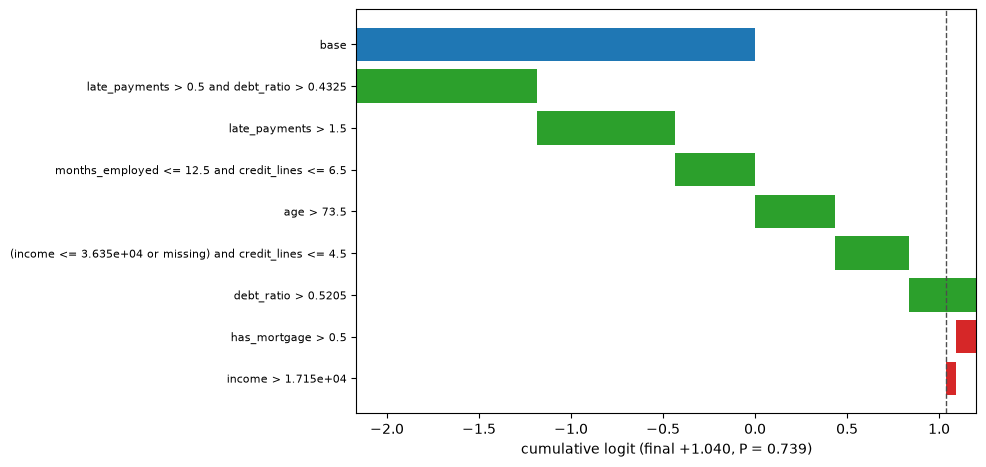

In [4]:
i = int(np.argmax(itm.predict_proba(X_test)[:, 1]))  # the riskiest test row
print(X_test.iloc[i])
itm.plot_contributions(X_test.iloc[i]);

## Effects against the truth

Most trees mix two features, so the effect of one feature is spread over several trees.
Its partial dependence in logit space adds them all up: set the feature to a value for
every row, average the logit. Below, that curve next to the true effect of the
simulation (both centered, since only differences in the logit matter).

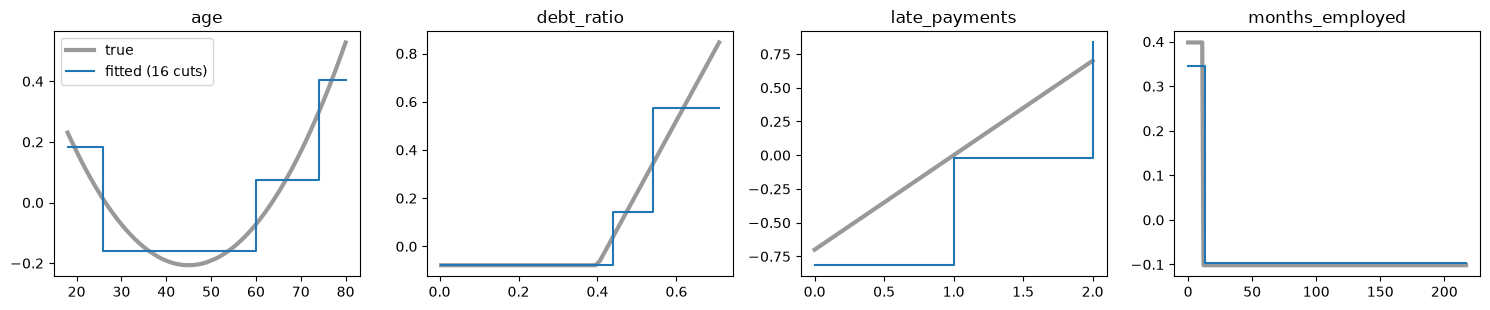

In [5]:
import matplotlib.pyplot as plt

from credit_data import true_effects

truth = true_effects()
sample = X_train.sample(2000, random_state=0)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, feature in zip(axes, ["age", "debt_ratio", "late_payments", "months_employed"]):
    grid = np.unique(np.quantile(X_train[feature].dropna(), np.linspace(0, 0.99, 60)))
    pd_logit = []
    for v in grid:
        Xv = sample.copy()
        Xv[feature] = v
        pd_logit.append(itm.decision_function(Xv).mean())
    pd_logit, true = np.array(pd_logit), truth[feature](grid)
    ax.plot(grid, true - true.mean(), color="0.6", lw=3, label="true")
    ax.step(grid, pd_logit - pd_logit.mean(), where="post", label="fitted (16 cuts)")
    ax.set_title(feature)
axes[0].legend()
plt.tight_layout()

With 16 cuts the model draws each effect as a few steps in the right places: the U of
age, the kink of the debt ratio at 0.4, the jump at one year of employment. More cuts
give finer steps.

## Deploying without the package

`to_dict()` is plain JSON: thresholds, leaf values and the base. Scoring is a few lines
in any language.

In [6]:
import json

spec = itm.to_dict(feature_names=list(X.columns))
print(json.dumps(spec, indent=1)[:800], "...")

{
 "link": "logit",
 "base_margin": -2.165874047452143,
 "classes": [
  0,
  1
 ],
 "trees": [
  {
   "rules": [
    {
     "conditions": [
      "late_payments <= 0.5"
     ],
     "value": -0.36385653108616955
    },
    {
     "conditions": [
      "late_payments > 0.5",
      "debt_ratio <= 0.4325"
     ],
     "value": 0.30772554275679276
    },
    {
     "conditions": [
      "late_payments > 0.5",
      "debt_ratio > 0.4325"
     ],
     "value": 0.9797930230510666
    }
   ]
  },
  {
   "rules": [
    {
     "conditions": [
      "(income <= 36350 or missing)",
      "credit_lines <= 4.5"
     ],
     "value": 0.4032865372978141
    },
    {
     "conditions": [
      "(income <= 36350 or missing)",
      "credit_lines > 4.5"
     ],
     "value": 0.09705966339641864
    },
    {
 ...


In [7]:
print(itm.export_text())

base (logit): -2.1659
tree 1
|--- late_payments <= 0.5
|   |--- value: -0.3639
|--- late_payments >  0.5
|   |--- debt_ratio <= 0.4325
|   |   |--- value: +0.3077
|   |--- debt_ratio >  0.4325
|   |   |--- value: +0.9798
tree 2
|--- income <= 3.635e+04
|   |--- credit_lines <= 4.5
|   |   |--- value: +0.4033
|   |--- credit_lines >  4.5
|   |   |--- value: +0.0971
|--- income >  3.635e+04
|   |--- income <= 5.085e+04
|   |   |--- value: -0.0432
|   |--- income >  5.085e+04
|   |   |--- value: -0.5047
tree 3
|--- late_payments <= 1.5
|   |--- value: -0.1066
|--- late_payments >  1.5
|   |--- value: +0.7493
tree 4
|--- months_employed <= 12.5
|   |--- credit_lines <= 6.5
|   |   |--- value: +0.4383
|   |--- credit_lines >  6.5
|   |   |--- value: -0.0227
|--- months_employed >  12.5
|   |--- age <= 25.5
|   |   |--- value: +0.2795
|   |--- age >  25.5
|   |   |--- value: -0.1646
tree 5
|--- age <= 73.5
|   |--- age <= 59.5
|   |   |--- value: -0.1296
|   |--- age >  59.5
|   |   |--- val